# 🌾 India Crop Yield Prediction — Notebook 3: Baseline Models

**Goal:** Train and evaluate multiple baseline regression models to establish performance benchmarks.  
Models covered: **Linear Regression, Ridge, Lasso, Decision Tree, KNN, SVR**

---

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print('Libraries loaded.')

Libraries loaded.


## 2. Load Processed Data

In [2]:
X_train = pd.read_csv('processed/X_train.csv')
X_val   = pd.read_csv('processed/X_val.csv')
X_test  = pd.read_csv('processed/X_test.csv')
y_train = pd.read_csv('processed/y_train.csv').squeeze()
y_val   = pd.read_csv('processed/y_val.csv').squeeze()
y_test  = pd.read_csv('processed/y_test.csv').squeeze()

with open('processed/feature_cols.json') as f:
    feature_cols = json.load(f)

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

Train: (12149, 16), Val: (2604, 16), Test: (2604, 16)


## 3. Evaluation Helper

In [3]:
def evaluate_model(name, model, X_tr, y_tr, X_v, y_v):
    """Fit model and return metrics dict."""
    model.fit(X_tr, y_tr)
    preds_tr = model.predict(X_tr)
    preds_v  = model.predict(X_v)

    def metrics(y_true, y_pred, split):
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae  = mean_absolute_error(y_true, y_pred)
        r2   = r2_score(y_true, y_pred)
        return {'Model': name, 'Split': split, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

    return metrics(y_tr, preds_tr, 'Train'), metrics(y_v, preds_v, 'Val')

print('Helper defined.')

Helper defined.


## 4. Define Baseline Models

In [4]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge (α=1.0)':     Ridge(alpha=1.0),
    'Lasso (α=0.1)':     Lasso(alpha=0.1, max_iter=5000),
    'ElasticNet':        ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000),
    'Decision Tree':     DecisionTreeRegressor(max_depth=8, min_samples_leaf=20, random_state=42),
    'KNN (k=10)':        KNeighborsRegressor(n_neighbors=10, n_jobs=-1),
    'SVR (RBF)':         SVR(kernel='rbf', C=10, epsilon=0.1),
}

print(f'{len(models)} baseline models defined.')

7 baseline models defined.


## 5. Train & Evaluate All Baselines

In [5]:
results = []
trained_models = {}

for name, model in models.items():
    print(f'Training: {name} ...', end=' ')
    tr_metrics, val_metrics = evaluate_model(name, model, X_train, y_train, X_val, y_val)
    results.extend([tr_metrics, val_metrics])
    trained_models[name] = model
    print(f'Val R²={val_metrics["R2"]:.4f}  Val RMSE={val_metrics["RMSE"]:.2f}')

results_df = pd.DataFrame(results)
print('\n=== All Baseline Results ===')
results_df

Training: Linear Regression ... Val R²=0.6437  Val RMSE=0.83
Training: Ridge (α=1.0) ... Val R²=0.6436  Val RMSE=0.83
Training: Lasso (α=0.1) ... Val R²=0.2117  Val RMSE=1.23
Training: ElasticNet ... Val R²=0.3056  Val RMSE=1.16
Training: Decision Tree ... Val R²=0.8176  Val RMSE=0.59
Training: KNN (k=10) ... Val R²=0.4216  Val RMSE=1.06
Training: SVR (RBF) ... Val R²=0.5632  Val RMSE=0.92

=== All Baseline Results ===


,Model,Split,RMSE,MAE,R2
0,Linear Regression,Train,0.804760,0.491350,0.667521
1,Linear Regression,Val,0.828768,0.502455,0.643705
2,Ridge (α=1.0),Train,0.804949,0.490939,0.667364
3,Ridge (α=1.0),Val,0.828927,0.501893,0.643569
4,Lasso (α=0.1),Train,1.236197,0.807345,0.215474
5,Lasso (α=0.1),Val,1.232742,0.808350,0.211707
6,ElasticNet,Train,1.156763,0.744480,0.313058
7,ElasticNet,Val,1.156983,0.746551,0.305621
8,Decision Tree,Train,0.552506,0.319254,0.843287
9,Decision Tree,Val,0.593008,0.351627,0.817584


## 6. Comparison Charts

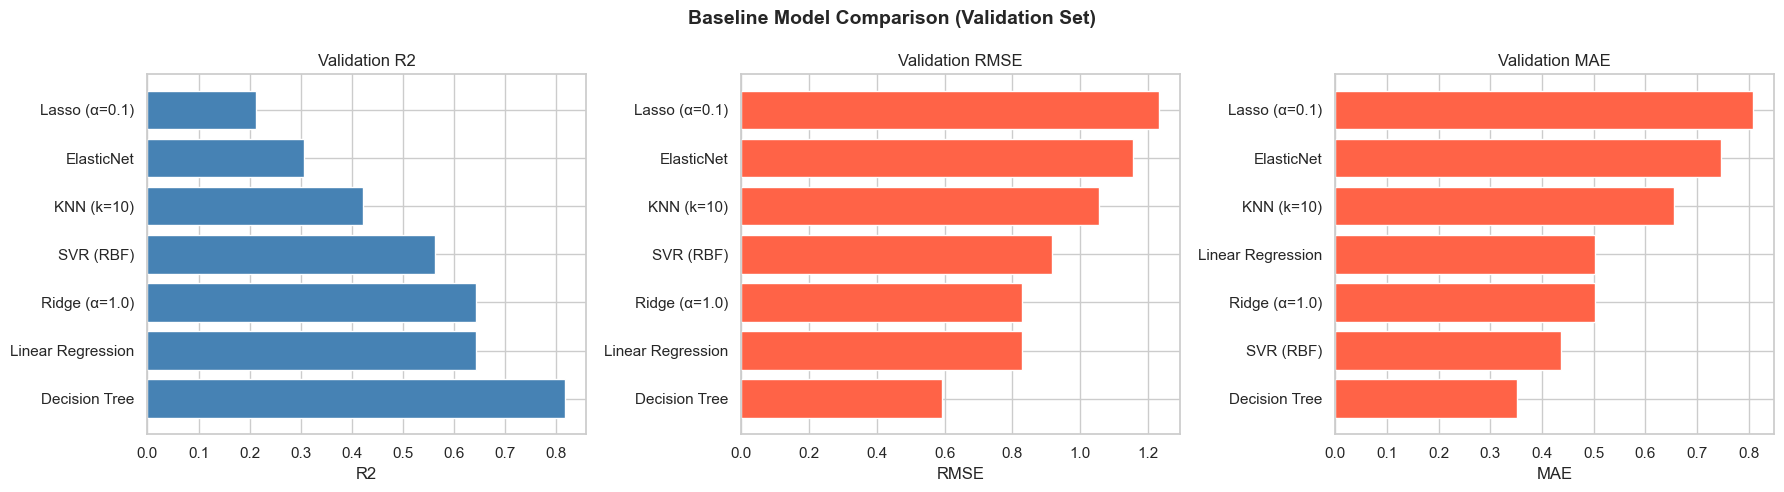

In [6]:
val_results = results_df[results_df['Split'] == 'Val'].sort_values('R2', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, ['R2', 'RMSE', 'MAE']):
    ascending = metric != 'R2'
    data = val_results.sort_values(metric, ascending=ascending)
    color = 'steelblue' if metric == 'R2' else 'tomato'
    ax.barh(data['Model'], data[metric], color=color, edgecolor='white')
    ax.set_title(f'Validation {metric}', fontsize=12)
    ax.set_xlabel(metric)

plt.suptitle('Baseline Model Comparison (Validation Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_comparison.png')
plt.show()

## 7. Residual Analysis — Best Baseline

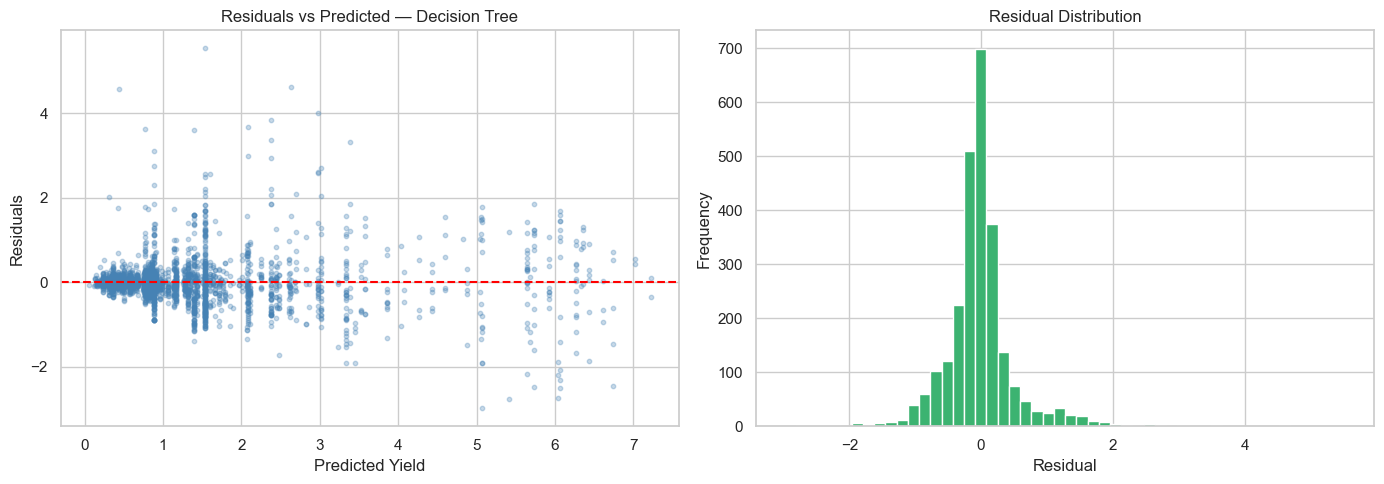

Best Baseline: Decision Tree
Val R² = 0.8176


In [7]:
best_name = val_results.iloc[0]['Model']
best_model = trained_models[best_name]

y_pred_val = best_model.predict(X_val)
residuals = y_val - y_pred_val

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual scatter
axes[0].scatter(y_pred_val, residuals, alpha=0.3, color='steelblue', s=10)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Yield')
axes[0].set_ylabel('Residuals')
axes[0].set_title(f'Residuals vs Predicted — {best_name}')

# Residual distribution
axes[1].hist(residuals, bins=50, color='mediumseagreen', edgecolor='white')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.savefig('baseline_residuals.png')
plt.show()

print(f'Best Baseline: {best_name}')
print(f'Val R² = {val_results.iloc[0]["R2"]:.4f}')

## 8. Actual vs Predicted Plot

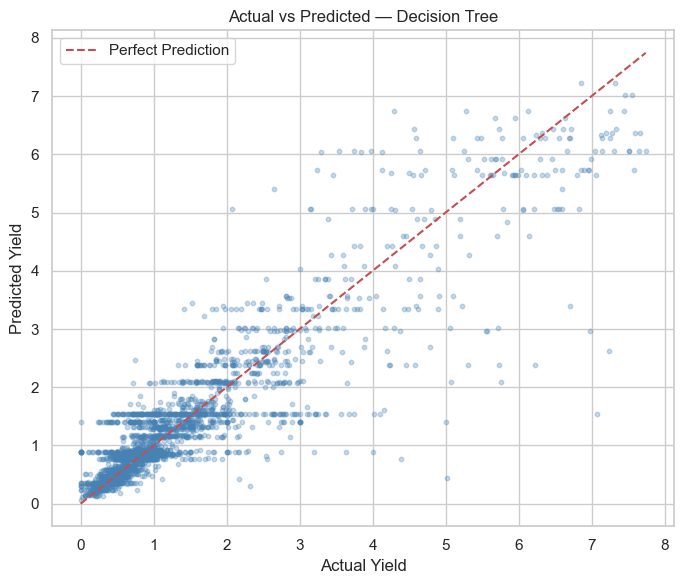

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_val, y_pred_val, alpha=0.3, color='steelblue', s=10)
mn, mx = min(y_val.min(), y_pred_val.min()), max(y_val.max(), y_pred_val.max())
ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect Prediction')
ax.set_xlabel('Actual Yield')
ax.set_ylabel('Predicted Yield')
ax.set_title(f'Actual vs Predicted — {best_name}')
ax.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted_baseline.png')
plt.show()

## 9. Save Best Baseline Model

In [9]:
import os
os.makedirs('models', exist_ok=True)

joblib.dump(best_model, f'models/baseline_best.pkl')
results_df.to_csv('models/baseline_results.csv', index=False)

print(f'Best baseline model ({best_name}) saved to models/baseline_best.pkl')
print('Results saved to models/baseline_results.csv')

Best baseline model (Decision Tree) saved to models/baseline_best.pkl
Results saved to models/baseline_results.csv


---
✅ **Baseline models complete.** Proceed to `04_advanced_models.ipynb`.